# Notebook 02 — BM25 Retrieval Baseline

Builds BM25 indexes for SciFact and NFCorpus, retrieves top-20 candidates, evaluates nDCG@10 / MRR@10 / Recall@20, and rebuilds the working pair tables with BM25 scores attached.

In [3]:
import os, sys
from pathlib import Path

# Always run from project root so relative paths (data/, configs/) resolve correctly
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

from src.utils.reproducibility import set_all_seeds
set_all_seeds(42)
print("Working directory:", os.getcwd())
print("Seeds set.")

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker
Seeds set.


## 1  Run SciFact pipeline

In [4]:
from src.retrieval.evaluate_retrieval import run_retrieval_pipeline

scifact_metrics, scifact_run_df = run_retrieval_pipeline(
    dataset_name="scifact",
    top_k=20,
)
print(scifact_metrics)

2026-03-28 18:33:48 | INFO     | src.data.loader | Loading scifact from data/raw/scifact (split=test) ...


  0%|          | 0/5183 [00:00<?, ?it/s]

2026-03-28 18:33:48 | INFO     | src.data.loader | Loaded scifact: 5183 docs, 300 queries, 339 qrel entries
2026-03-28 18:33:48 | INFO     | src.retrieval.bm25_index | Loading cached BM25 index from data/caches/bm25_indexes/scifact
2026-03-28 18:33:48 | INFO     | src.retrieval.bm25_index | Loaded BM25 index: 5,183 documents from data/caches/bm25_indexes/scifact


BM25 retrieval: 100%|██████████| 300/300 [00:02<00:00, 114.76query/s]

2026-03-28 18:33:51 | INFO     | src.retrieval.bm25_retriever | Retrieval complete: 300 queries, 6000 total candidates (top-20)

  scifact — BM25 Baseline
               ndcg@10  mrr@10  recall@20
BM25 (top-20)   0.5597  0.5242     0.7370

2026-03-28 18:33:51 | INFO     | src.retrieval.evaluate_retrieval | Saved BM25 run -> data/interim/scifact/bm25_top20.parquet


2026-03-28 18:33:51 | INFO     | src.data.pair_builder | Built run-based pair table: 6000 pairs (245 relevant, 5755 non-relevant)
2026-03-28 18:33:51 | INFO     | src.data.pair_builder | Saved pair table to data/interim/scifact/query_doc_pairs.parquet
2026-03-28 18:33:51 | INFO     | src.retrieval.evaluate_retrieval | Working pair table updated: 6000 pairs (245 relevant / 5755 non-relevant)
{'ndcg@10': 0.5597016150134456, 'mrr@10': 0.5242208994708994, 'recall@20': 0.737}


## 2  Run NFCorpus pipeline

In [5]:
nfcorpus_metrics, nfcorpus_run_df = run_retrieval_pipeline(
    dataset_name="nfcorpus",
    top_k=20,
)
print(nfcorpus_metrics)

2026-03-28 18:33:54 | INFO     | src.data.loader | Loading nfcorpus from data/raw/nfcorpus (split=test) ...


  0%|          | 0/3633 [00:00<?, ?it/s]

2026-03-28 18:33:54 | INFO     | src.data.loader | Loaded nfcorpus: 3633 docs, 323 queries, 12334 qrel entries
2026-03-28 18:33:54 | INFO     | src.retrieval.bm25_index | Loading cached BM25 index from data/caches/bm25_indexes/nfcorpus
2026-03-28 18:33:54 | INFO     | src.retrieval.bm25_index | Loaded BM25 index: 3,633 documents from data/caches/bm25_indexes/nfcorpus


BM25 retrieval: 100%|██████████| 323/323 [00:00<00:00, 699.64query/s]

2026-03-28 18:33:55 | INFO     | src.retrieval.bm25_retriever | Retrieval complete: 323 queries, 6460 total candidates (top-20)

  nfcorpus — BM25 Baseline
               ndcg@10  mrr@10  recall@20
BM25 (top-20)   0.2666  0.4669     0.1446

2026-03-28 18:33:55 | INFO     | src.retrieval.evaluate_retrieval | Saved BM25 run -> data/interim/nfcorpus/bm25_top20.parquet


2026-03-28 18:33:55 | INFO     | src.data.pair_builder | Built run-based pair table: 6460 pairs (883 relevant, 5577 non-relevant)
2026-03-28 18:33:55 | INFO     | src.data.pair_builder | Saved pair table to data/interim/nfcorpus/query_doc_pairs.parquet
2026-03-28 18:33:55 | INFO     | src.retrieval.evaluate_retrieval | Working pair table updated: 6460 pairs (883 relevant / 5577 non-relevant)
{'ndcg@10': 0.2666459356136742, 'mrr@10': 0.46694923583468473, 'recall@20': 0.14456696501723454}


## 3  Combined metrics table

In [6]:
from src.evaluation.results_table import print_metrics

print_metrics(
    {
        "BM25 SciFact  (top-20)": scifact_metrics,
        "BM25 NFCorpus (top-20)": nfcorpus_metrics,
    },
    title="BM25 Retrieval Baseline",
)


  BM25 Retrieval Baseline
                        ndcg@10  mrr@10  recall@20
BM25 SciFact  (top-20)   0.5597  0.5242     0.7370
BM25 NFCorpus (top-20)   0.2666  0.4669     0.1446



## 4  Inspect SciFact run DataFrame

In [7]:
print("SciFact run shape:", scifact_run_df.shape)
print("Columns:", list(scifact_run_df.columns))
scifact_run_df.head(10)

SciFact run shape: (6000, 4)
Columns: ['query_id', 'doc_id', 'bm25_score', 'bm25_rank']


,query_id,doc_id,bm25_score,bm25_rank
0,1,825728,9.489886,1
1,1,10931595,8.945226,2
2,1,43385013,7.586050,3
3,1,13231899,7.439832,4
4,1,18953920,7.035655,5
5,1,17388232,6.911388,6
6,1,45638119,6.904247,7
7,1,24998637,6.868012,8
8,1,17518195,6.781555,9
9,1,25298276,6.722989,10


## 5  Score distribution by rank

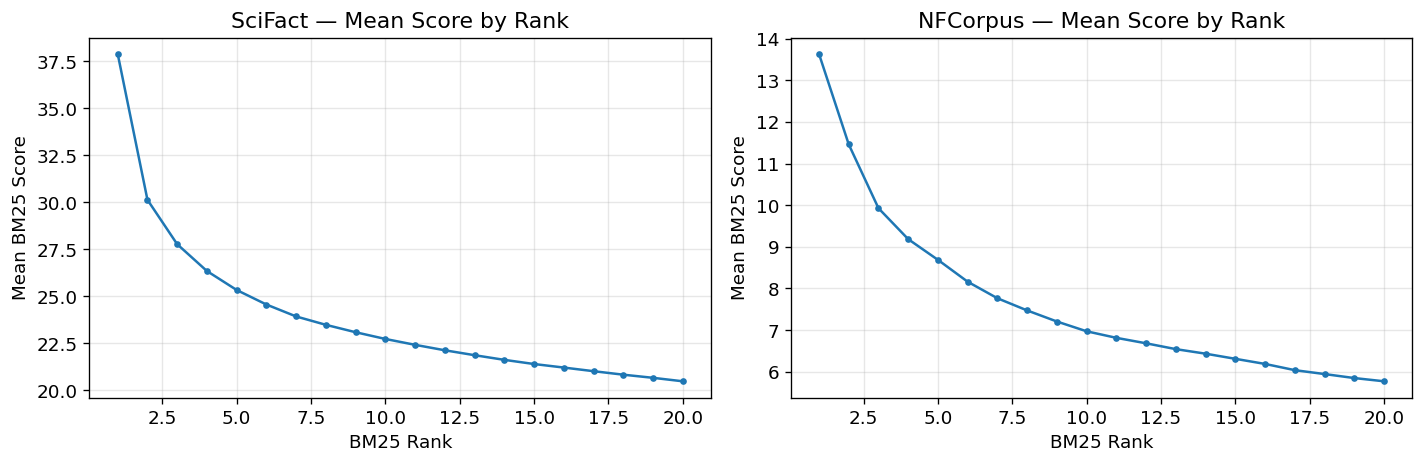

Saved figure.


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, name) in zip(axes, [(scifact_run_df, "SciFact"), (nfcorpus_run_df, "NFCorpus")]):
    rank_mean = df.groupby("bm25_rank")["bm25_score"].mean()
    ax.plot(rank_mean.index, rank_mean.values, marker="o", markersize=3)
    ax.set_xlabel("BM25 Rank")
    ax.set_ylabel("Mean BM25 Score")
    ax.set_title(f"{name} — Mean Score by Rank")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
import pathlib; pathlib.Path("outputs/midproject/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/midproject/figures/bm25_score_by_rank.png", bbox_inches="tight")
plt.show()
print("Saved figure.")

## 6  Verify working pair tables

In [9]:
import pandas as pd

for name in ["scifact", "nfcorpus"]:
    pairs = pd.read_parquet(f"data/interim/{name}/query_doc_pairs.parquet")
    print(f"\n{name} pair table shape: {pairs.shape}")
    print("Columns:", list(pairs.columns))
    print("Relevant:", pairs["is_relevant"].sum(), "/ Non-relevant:", (~pairs["is_relevant"]).sum())
    print(pairs[["bm25_score", "bm25_rank"]].describe().round(3))


scifact pair table shape: (6000, 10)
Columns: ['query_id', 'doc_id', 'query_text', 'doc_title', 'doc_text', 'relevance_label', 'is_relevant', 'dataset', 'bm25_score', 'bm25_rank']
Relevant: 245 / Non-relevant: 5755
       bm25_score  bm25_rank
count    6000.000   6000.000
mean       23.951     10.500
std        11.231      5.767
min         5.480      1.000
25%        16.433      5.750
50%        21.449     10.500
75%        29.545     15.250
max       123.035     20.000

nfcorpus pair table shape: (6460, 10)
Columns: ['query_id', 'doc_id', 'query_text', 'doc_title', 'doc_text', 'relevance_label', 'is_relevant', 'dataset', 'bm25_score', 'bm25_rank']
Relevant: 883 / Non-relevant: 5577
       bm25_score  bm25_rank
count    6460.000   6460.000
mean        7.652     10.500
std         6.098      5.767
min         0.000      1.000
25%         0.000      5.750
50%         7.567     10.500
75%        11.724     15.250
max        45.734     20.000


## 7  BM25 score distribution: relevant vs non-relevant

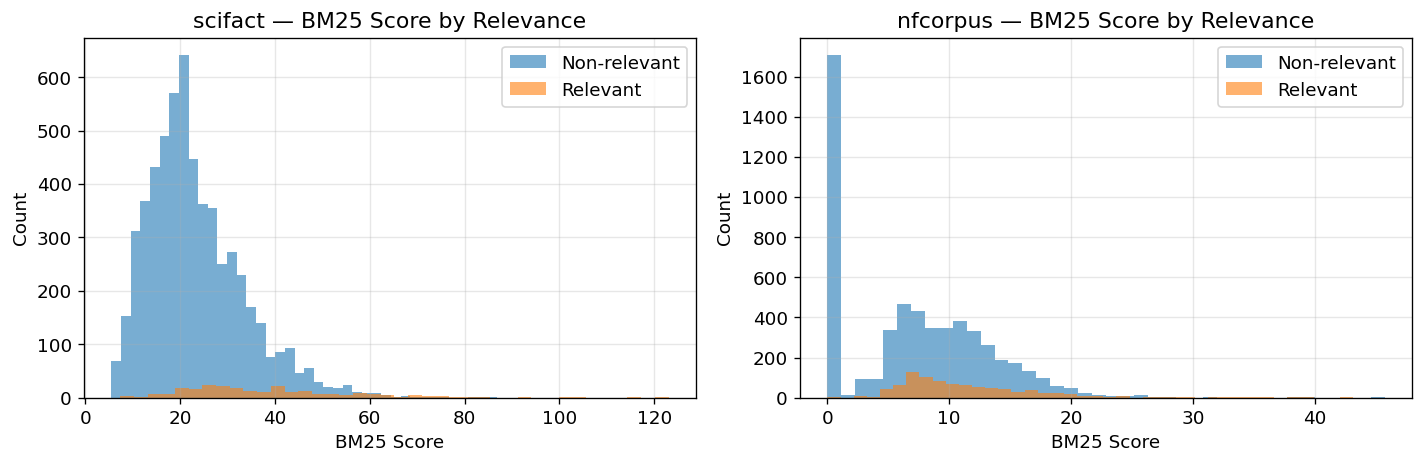

Saved figure.


In [10]:
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name in zip(axes, ["scifact", "nfcorpus"]):
    pairs = pd.read_parquet(f"data/interim/{name}/query_doc_pairs.parquet")
    for label, grp in pairs.groupby("is_relevant"):
        ax.hist(grp["bm25_score"], bins=40, alpha=0.6,
                label=f"{'Relevant' if label else 'Non-relevant'}")
    ax.set_xlabel("BM25 Score")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} — BM25 Score by Relevance")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/midproject/figures/bm25_score_relevance.png", bbox_inches="tight")
plt.show()
print("Saved figure.")